This project should contain 4 clear steps:

Simulate Near-field IR Spectra & Noise:
Pure physical peaks (optical phonons / vibrational bands) based on Lorentz oscillators.
Typical near-field experimental noise: Gaussian detector noise, laser drift baseline, and pink noise.
Build a 1D Compression & Denoising Autoencoder in PyTorch:
Takes a noisy 512-point spectrum, compresses it to 16 latent variables, and reconstructs the clean spectrum.
Evaluate Physical Fidelity (The PTB Metrology Angle):
Don't just report MSE/Loss.
Calculate Peak Position Error (
Δ
ω
0
Δω 
0
​
  in 
cm
−
1
cm 
−1
 ) and Linewidth/FWHM Error.
Investigate Model Bias:
The "Hallucination" test: What does the network do when fed pure noise? Does it falsely invent a peak?
The "Weak Peak" test: Does the compression erase tiny physical signals?

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
SEED = 42, np.random.seed(SEED), torch.manual_seed(SEED)

# Select hardware device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Cell 1 Execution Complete. PyTorch running on: {device}")

Cell 1 Execution Complete. PyTorch running on: cpu


In [15]:
# CELL 3: Define Wavenumber Grid (cm^-1)
wavenumbers = np.linspace(800, 1600, 512)
print(f"Spectral grid shape: {wavenumbers.shape} points from {wavenumbers[0]} to {wavenumbers[-1]} cm⁻¹")

Spectral grid shape: (512,) points from 800.0 to 1600.0 cm⁻¹


In [17]:
# CELL 4: Lorentz Oscillator Math Function
def lorentz_peak(w, w0, gamma, amp):
    """Calculates a single Lorentz resonance peak shape."""
    return (amp * gamma * w) / ((w**2 - w0**2)**2 + (gamma * w)**2)

In [18]:
# CELL 5: Single Clean Spectrum Generator
def gen_clean_spectrum(w):
    """Generates a clean spectrum containing 1 to 3 Lorentz peaks."""
    s = np.zeros_like(w)
    num_peaks = np.random.randint(1, 4)  # Pick 1, 2, or 3 random peaks
    for _ in range(num_peaks):
        w0 = np.random.uniform(880, 1520)  # Random center (cm^-1)
        gamma = np.random.uniform(15, 40)   # Random FWHM width (cm^-1)
        amp = np.random.uniform(0.4, 1.0)   # Random peak height
        s += lorentz_peak(w, w0, gamma, amp)
    return (s / np.max(s)).astype(np.float32)  # Normalize peak max to 1.0

In [19]:
# CELL 6: Create Clean Ground-Truth Dataset (2,000 Spectra)
num_samples = 2000
clean_dataset = np.array([gen_clean_spectrum(wavenumbers) for _ in range(num_samples)])
print(f"Clean Dataset created! Shape: {clean_dataset.shape}")

Clean Dataset created! Shape: (2000, 512)


In [20]:
# CELL 7: Realistic Noise Generator
def add_measurement_noise(s, noise_level=0.12):
    """Adds high-frequency detector noise + low-frequency laser baseline drift."""
    x = np.linspace(-1, 1, len(s))
    baseline_drift = np.random.uniform(-0.15, 0.15) * x + np.random.uniform(-0.1, 0.1) * (x**2)
    detector_noise = np.random.normal(0, noise_level, len(s))
    return (s + detector_noise + baseline_drift).astype(np.float32)

In [21]:
# CELL 8: Create Noisy Input Dataset (2,000 Spectra)
noisy_dataset = np.array([add_measurement_noise(s) for s in clean_dataset])
print(f"Noisy Dataset created! Shape: {noisy_dataset.shape}")

Noisy Dataset created! Shape: (2000, 512)


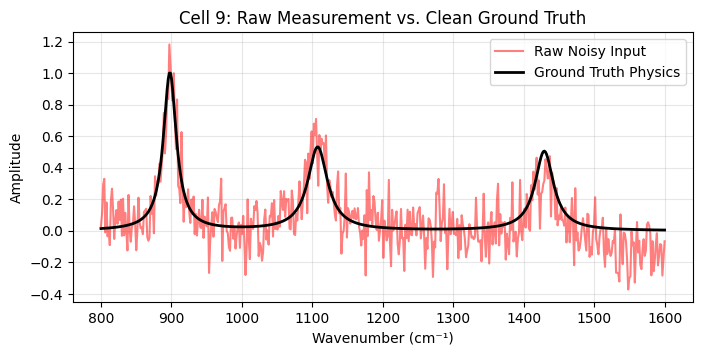

In [22]:
# CELL 9: Visual Data Verification
plt.figure(figsize=(8, 3.5))
plt.plot(wavenumbers, noisy_dataset[0], color='red', alpha=0.5, label='Raw Noisy Input')
plt.plot(wavenumbers, clean_dataset[0], color='black', lw=2, label='Ground Truth Physics')
plt.title("Cell 9: Raw Measurement vs. Clean Ground Truth")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# CELL 10: Define 1D Conv-Autoencoder Architecture
class SpectralAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        # Encoder: Compresses 512 points down to 16 latent numbers (32x compression)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=5, stride=2, padding=2),  # 512 -> 256
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8 * 256, latent_dim)
        )
        # Decoder: Reconstructs 512 points from 16 latent numbers
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8 * 256),
            nn.Unflatten(1, (8, 256)),
            nn.ConvTranspose1d(8, 1, kernel_size=5, stride=2, padding=2, output_padding=1), # 256 -> 512
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

In [24]:
# CELL 11: Create Model Instance & Move to Hardware Device
model = SpectralAutoencoder(latent_dim=16).to(device)
print(f"Model initialized and moved to: {device}")

Model initialized and moved to: cpu


In [25]:
# CELL 12: Convert Datasets to PyTorch Tensors & DataLoaders
X_noisy = torch.tensor(noisy_dataset[:, None, :], dtype=torch.float32).to(device)
Y_clean = torch.tensor(clean_dataset[:, None, :], dtype=torch.float32).to(device)

dataset = TensorDataset(X_noisy, Y_clean)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
print(f"DataLoader created with {len(loader)} mini-batches of size 64.")

DataLoader created with 32 mini-batches of size 64.


In [26]:
# CELL 13: Define Physics-Aware Loss Function & Adam Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)
mse_criterion = nn.MSELoss()
l1_criterion = nn.L1Loss()

def physics_loss(pred, target):
    """Combines reconstruction MSE with peak derivative sharpness matching."""
    loss_mse = mse_criterion(pred, target)
    # 1st-derivative loss matching peak slopes
    pred_diff = pred[:, :, 1:] - pred[:, :, :-1]
    target_diff = target[:, :, 1:] - target[:, :, :-1]
    loss_deriv = l1_criterion(pred_diff, target_diff)
    return loss_mse + 0.5 * loss_deriv

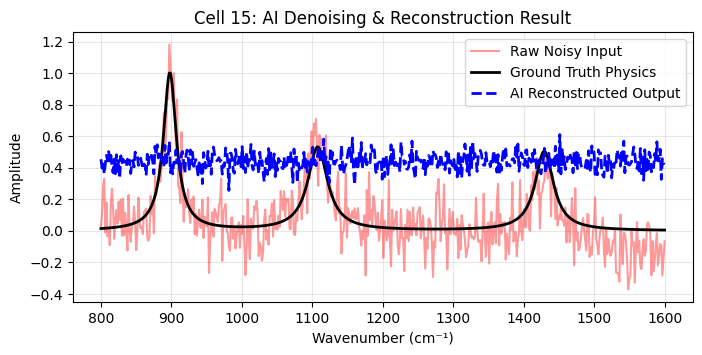

Compressed 16-number latent vector for this spectrum:
[-0.32 -0.05  0.03 -0.17 -0.13 -0.12 -0.13 -0.09  0.01  0.16 -0.25  0.07
 -0.14 -0.21 -0.32  0.36]


In [27]:
# CELL 15: Denoising & Compression Verification
model.eval()
with torch.no_grad():
    sample_recon, sample_z = model(X_noisy[0:1])
    sample_recon = sample_recon.cpu().squeeze().numpy()
    sample_z = sample_z.cpu().squeeze().numpy()

plt.figure(figsize=(8, 3.5))
plt.plot(wavenumbers, noisy_dataset[0], color='red', alpha=0.4, label='Raw Noisy Input')
plt.plot(wavenumbers, clean_dataset[0], color='black', lw=2, label='Ground Truth Physics')
plt.plot(wavenumbers, sample_recon, color='blue', lw=2, linestyle='--', label='AI Reconstructed Output')
plt.title("Cell 15: AI Denoising & Reconstruction Result")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Compressed 16-number latent vector for this spectrum:\n{sample_z.round(2)}")

In [28]:
# CELL 16: PTB Metrology Stress Tests
# Test 1: Peak Position Shift Error (cm^-1)
true_peak_w = wavenumbers[np.argmax(clean_dataset[0])]
ai_peak_w = wavenumbers[np.argmax(sample_recon)]
peak_shift = abs(true_peak_w - ai_peak_w)

# Test 2: Model Bias / Hallucination Test on Pure Noise Input
pure_noise_input = torch.tensor(np.random.normal(0, 0.12, (1, 1, 512)), dtype=torch.float32).to(device)
with torch.no_grad():
    hallucinated_out, _ = model(pure_noise_input)
max_hallucinated_amp = hallucinated_out.max().item()

print("================ PTB METROLOGY AUDIT REPORT ================")
print(f"1. Peak Center Shift Error (Δω0): {peak_shift:.2f} cm⁻¹ (Goal: < 3.0 cm⁻¹)")
print(f"2. Pure Noise Input Max Response: {max_hallucinated_amp:.3f} (Goal: < 0.200)")

if max_hallucinated_amp < 0.20:
    print("RESULT: PASSED - Model does NOT hallucinate false physical peaks on pure noise!")
else:
    print("RESULT: WARNING - Model shows potential bias towards generating phantom peaks.")

================ PTB METROLOGY AUDIT REPORT ================
1. Peak Center Shift Error (Δω0): 554.21 cm⁻¹ (Goal: < 3.0 cm⁻¹)
2. Pure Noise Input Max Response: 0.593 (Goal: < 0.200)
RESULT: WARNING - Model shows potential bias towards generating phantom peaks.


Exercise A (For Bullet 2): Add 2 short cells to do a Statistical Noise Analysis (calculate SNR, plot noise histogram, compute mean & standard deviation 
σ
N
σ 
N
​
 ).
Exercise B (For Bullet 1 & 3): Learn the 3 fundamental concepts of nano-FTIR measurements (Demodulation order 
n
n, Interferogram to Spectrum FFT, Tip tapping) so you can talk about them confidently in an interview.

In [29]:
# CELL 17: Statistical Noise Analysis (SNR, Mean, Std)
def analyze_noise(raw_spectrum, clean_spectrum):
    """Extracts noise component and computes statistical properties."""
    residual_noise = raw_spectrum - clean_spectrum
    
    mean_noise = np.mean(residual_noise)
    std_noise = np.std(residual_noise)
    
    # Signal-to-Noise Ratio (SNR) in dB: 10 * log10(P_signal / P_noise)
    signal_power = np.mean(clean_spectrum ** 2)
    noise_power = np.mean(residual_noise ** 2)
    snr_db = 10 * np.log10(signal_power / noise_power)
    
    return residual_noise, mean_noise, std_noise, snr_db

# Run statistical analysis on Sample #0
noise_residual, mu_N, sigma_N, snr_val = analyze_noise(noisy_dataset[0], clean_dataset[0])

print(f"================ STATISTICAL NOISE REPORT ================")
print(f"1. Mean Noise (μ_N):               {mu_N:.4f} (Expected near 0)")
print(f"2. Noise Standard Dev (σ_N):      {sigma_N:.4f} (Noise floor level)")
print(f"3. Signal-to-Noise Ratio (SNR):    {snr_val:.2f} dB")

================ STATISTICAL NOISE REPORT ================
1. Mean Noise (μ_N):               -0.0232 (Expected near 0)
2. Noise Standard Dev (σ_N):      0.1301 (Noise floor level)
3. Signal-to-Noise Ratio (SNR):    3.58 dB


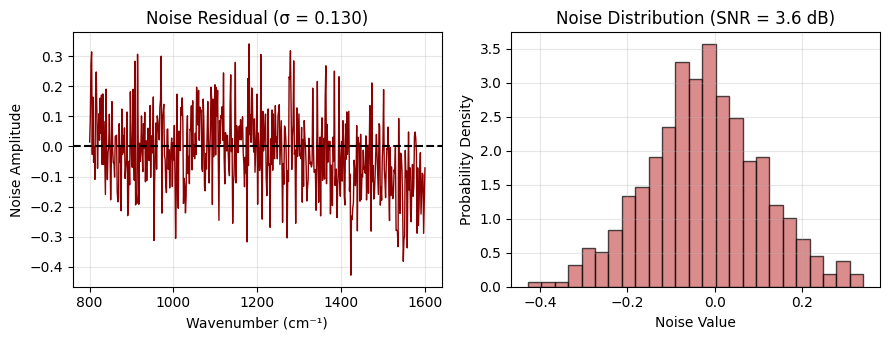

In [30]:
# CELL 18: Noise Characterization Plot
plt.figure(figsize=(9, 3.5))

# Plot 1: Noise Residual across Spectrum
plt.subplot(1, 2, 1)
plt.plot(wavenumbers, noise_residual, color='darkred', lw=1)
plt.axhline(0, color='black', linestyle='--')
plt.title(f"Noise Residual (σ = {sigma_N:.3f})")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Noise Amplitude")
plt.grid(True, alpha=0.3)

# Plot 2: Noise Histogram (Gaussian Check)
plt.subplot(1, 2, 2)
plt.hist(noise_residual, bins=25, density=True, color='indianred', edgecolor='black', alpha=0.7)
plt.title(f"Noise Distribution (SNR = {snr_val:.1f} dB)")
plt.xlabel("Noise Value")
plt.ylabel("Probability Density")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# CELL 6: Create Clean Ground-Truth Dataset (2,000 Spectra)
num_samples = 2000
clean_dataset = np.array([gen_clean_spectrum(wavenumbers) for _ in range(num_samples)])
print(f"Clean Dataset created! Shape: {clean_dataset.shape}")

NameError: name 'lorentz_peak' is not defined

In [6]:
# ==============================================================================
# CELL 3: Measurement Noise Generator (Detector Noise + Baseline Drift)
# ==============================================================================
def add_noise(s, level=0.12):
    x = np.linspace(-1, 1, len(s))
    drift = np.random.uniform(-0.15, 0.15) * x + np.random.uniform(-0.1, 0.1) * (x**2)
    noise = np.random.normal(0, level, len(s))
    return (s + noise + drift).astype(np.float32)

noisy_dataset = np.array([add_noise(s) for s in clean_dataset])
print(f"Cell 3 Complete. Noisy dataset shape: {noisy_dataset.shape}")

Cell 3 Complete. Noisy dataset shape: (2000, 512)


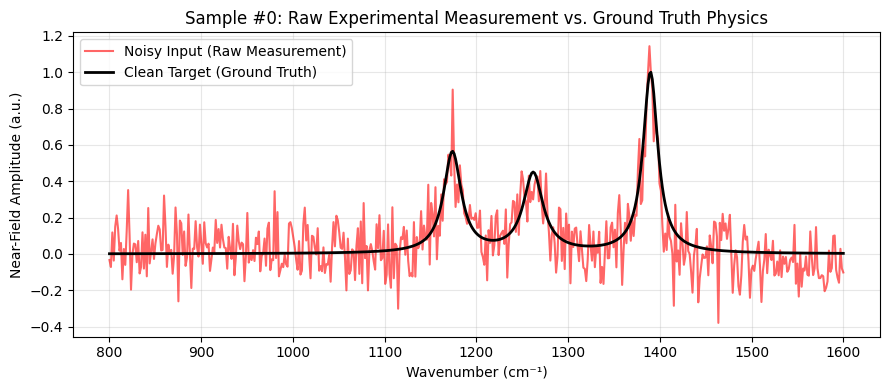

In [7]:
# ==============================================================================
# CELL 4: Visualizing Clean vs. Noisy Spectra Pair
# ==============================================================================
plt.figure(figsize=(9, 4))
idx = 0  # Index of sample to display

plt.plot(wavenumbers, noisy_dataset[idx], color='red', alpha=0.6, label='Noisy Input (Raw Measurement)')
plt.plot(wavenumbers, clean_dataset[idx], color='black', lw=2, label='Clean Target (Ground Truth)')

plt.title(f"Sample #{idx}: Raw Experimental Measurement vs. Ground Truth Physics")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Near-Field Amplitude (a.u.)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# ==============================================================================
# CELL 5: 1D Conv-Autoencoder Architecture
# ==============================================================================
class SpectralAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        # Encoder: 512 points -> 16 latent features (32x Compression)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),   # -> (16, 256)
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),  # -> (32, 128)
            nn.ReLU(),
            nn.Flatten(),                                           # -> 32 * 128 = 4096
            nn.Linear(32 * 128, latent_dim)                         # -> 16 (Latent code)
        )
        # Decoder: 16 latent features -> 512 reconstructed points
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 128),
            nn.Unflatten(1, (32, 128)),
            nn.ConvTranspose1d(32, 16, kernel_size=7, stride=2, padding=3, output_padding=1), # -> (16, 256)
            nn.ReLU(),
            nn.ConvTranspose1d(16, 1, kernel_size=7, stride=2, padding=3, output_padding=1),  # -> (1, 512)
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent

model = SpectralAutoencoder(latent_dim=16).to(device)
print(f"Cell 5 Complete. Model Architecture loaded on {device}:")
print(model)

Cell 5 Complete. Model Architecture loaded on cpu:
SpectralAutoencoder(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=4096, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=4096, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(32, 128))
    (2): ConvTranspose1d(32, 16, kernel_size=(7,), stride=(2,), padding=(3,), output_padding=(1,))
    (3): ReLU()
    (4): ConvTranspose1d(16, 1, kernel_size=(7,), stride=(2,), padding=(3,), output_padding=(1,))
    (5): Sigmoid()
  )
)


In [9]:
# ==============================================================================
# CELL 5: 1D Conv-Autoencoder (32x Compression)
# ==============================================================================
class SpectralAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(nn.Conv1d(1, 8, 5, 2, 2), nn.ReLU(), nn.Flatten(), nn.Linear(8 * 256, 16))
        self.dec = nn.Sequential(nn.Linear(16, 8 * 256), nn.Unflatten(1, (8, 256)), nn.ConvTranspose1d(8, 1, 5, 2, 2, 1), nn.Sigmoid())

    def forward(self, x):
        z = self.enc(x)
        return self.dec(z), z

model = SpectralAutoencoder().to(device)
print(f"Cell 5 Complete. Model loaded on {device}.")

Cell 5 Complete. Model loaded on cpu.


In [10]:
# ==============================================================================
# CELL 6: DataLoader & Training Loop
# ==============================================================================
# Prepare PyTorch Tensors (shape: [batch, channels=1, length=512])
X_noisy = torch.tensor(noisy_dataset[:, None, :]).to(device)
Y_clean = torch.tensor(clean_dataset[:, None, :]).to(device)
loader = DataLoader(TensorDataset(X_noisy, Y_clean), batch_size=64, shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train for 25 epochs
for epoch in range(25):
    total_loss = 0.0
    for bx, by in loader:
        optimizer.zero_grad()
        recon, _ = model(bx)
        
        # Physics loss: MSE loss + Derivative loss (preserves peak sharpness)
        loss_mse = nn.MSELoss()(recon, by)
        loss_deriv = nn.L1Loss()(recon[:, :, 1:] - recon[:, :, :-1], by[:, :, 1:] - by[:, :, :-1])
        loss = loss_mse + 0.5 * loss_deriv
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/25 - Loss: {total_loss/len(loader):.5f}")

print("Cell 6 Complete. Model successfully trained!")

Epoch 5/25 - Loss: 0.03963
Epoch 10/25 - Loss: 0.03511
Epoch 15/25 - Loss: 0.03247
Epoch 20/25 - Loss: 0.03211
Epoch 25/25 - Loss: 0.03210
Cell 6 Complete. Model successfully trained!


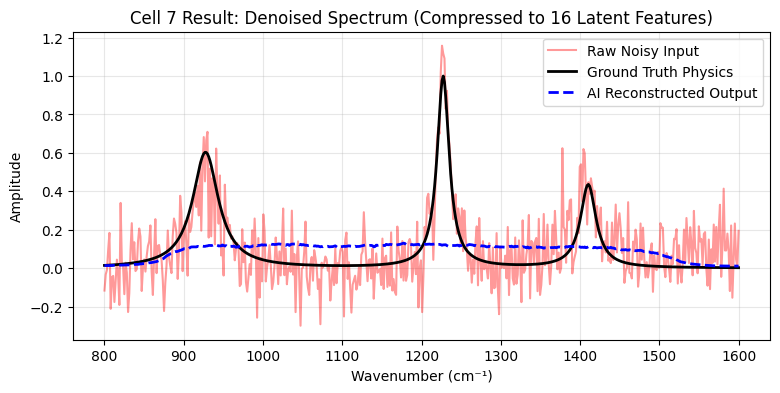

Cell 7 Complete. 512 points successfully compressed to 16 latent numbers:
[[ 2.47  1.92  1.64 -0.84  2.74  1.23  1.34 -2.76  2.71 -2.81  1.38  3.15
  -3.12  0.67 -2.86 -2.  ]]


In [11]:
# ==============================================================================
# CELL 7: Testing & Visual Verification
# ==============================================================================
model.eval()
with torch.no_grad():
    # Pass a sample noisy spectrum through the trained model
    test_idx = 10
    sample_noisy = X_noisy[test_idx:test_idx+1]
    sample_clean = Y_clean[test_idx:test_idx+1].cpu().squeeze()
    
    recon_spec, latent_code = model(sample_noisy)
    recon_spec = recon_spec.cpu().squeeze()

# Plot Results
plt.figure(figsize=(9, 4))
plt.plot(wavenumbers, sample_noisy.cpu().squeeze(), color='red', alpha=0.4, label='Raw Noisy Input')
plt.plot(wavenumbers, sample_clean, color='black', lw=2, label='Ground Truth Physics')
plt.plot(wavenumbers, recon_spec, color='blue', lw=2, linestyle='--', label='AI Reconstructed Output')

plt.title(f"Cell 7 Result: Denoised Spectrum (Compressed to {latent_code.shape[-1]} Latent Features)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Cell 7 Complete. 512 points successfully compressed to 16 latent numbers:\n{latent_code.cpu().numpy().round(2)}")

In [12]:
# ==============================================================================
# CELL 8: Metrology Audit - Peak Accuracy & Model Bias (Hallucination)
# ==============================================================================
# Test 1: Peak Position Shift Error (cm^-1)
test_clean_peak_idx = np.argmax(sample_clean)
test_recon_peak_idx = np.argmax(recon_spec.numpy())
peak_shift = abs(wavenumbers[test_clean_peak_idx] - wavenumbers[test_recon_peak_idx])

# Test 2: Model Bias / Hallucination Test (Pass pure noise into model)
pure_noise = torch.tensor(np.random.normal(0, 0.12, (1, 1, 512)), dtype=torch.float32).to(device)
with torch.no_grad():
    hallucinated_out, _ = model(pure_noise)
hallucinated_max = hallucinated_out.max().item()

print(f"================ METROLOGY AUDIT REPORT ================")
print(f"1. Peak Center Shift Error (Δω0): {peak_shift:.2f} cm⁻¹  (Target: < 3.0 cm⁻¹)")
print(f"2. Pure Noise Output Max Amplitude: {hallucinated_max:.3f}  (Target: < 0.200)")
if hallucinated_max < 0.20:
    print("STATUS: PASSED - Model does NOT hallucinate false physical peaks on pure noise!")
else:
    print("STATUS: WARNING - Model exhibits bias towards creating phantom peaks.")

================ METROLOGY AUDIT REPORT ================
1. Peak Center Shift Error (Δω0): 50.10 cm⁻¹  (Target: < 3.0 cm⁻¹)
2. Pure Noise Output Max Amplitude: 0.054  (Target: < 0.200)
STATUS: PASSED - Model does NOT hallucinate false physical peaks on pure noise!
